# An e-commerce company,ShopSmart, wants to better understand the behaviour of visitors browsing its online store.

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [24]:
df=pd.read_csv("shop_smart_ecommerce.csv")

In [25]:
df.head(100)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0.0,0,0.0,2,33.000000,0.000000,0.100000,0.0,0.2,Feb,1,1,1,3,Returning_Visitor,False,False
96,0,0.0,0,0.0,6,1566.500000,0.050000,0.066667,0.0,0.2,Feb,1,1,1,3,Returning_Visitor,False,False
97,0,0.0,0,0.0,4,105.000000,0.000000,0.025000,0.0,0.6,Feb,1,1,1,4,Returning_Visitor,False,False
98,0,0.0,1,0.0,7,50.000000,0.038095,0.080952,0.0,0.6,Feb,2,4,1,7,Returning_Visitor,False,False


In [26]:
df.isnull().sum()
#so dataset does not contains the null values so we dont need to do the part of the data filling

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Weekend"]=le.fit_transform(df["Weekend"])
df["Revenue"]=le.fit_transform(df["Revenue"])

#so in this sitution we encode the ture false values of the weekend and renvenur in the 0 & 1 

In [28]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


In [29]:
cols = ["Month", "VisitorType"]

# Explicitly setting sparse_output=False ensures it returns a regular NumPy array
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])

# Convert back to a DataFrame safely
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

# Drop original columns and concatenate horizontally
df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [30]:
 df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [35]:
X=df.drop("Revenue",axis=1)
y=df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)


DecisionTreeClassifier()

In [36]:
y_pred=model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, f1_score,classification_report,confusion_matrix
score = f1_score(y_test, y_pred)
print("f1 score is: ",score)
print("accuracy: ",accuracy_score(y_test,y_pred))



f1 score is:  0.6289473684210526
accuracy:  0.8856447688564477


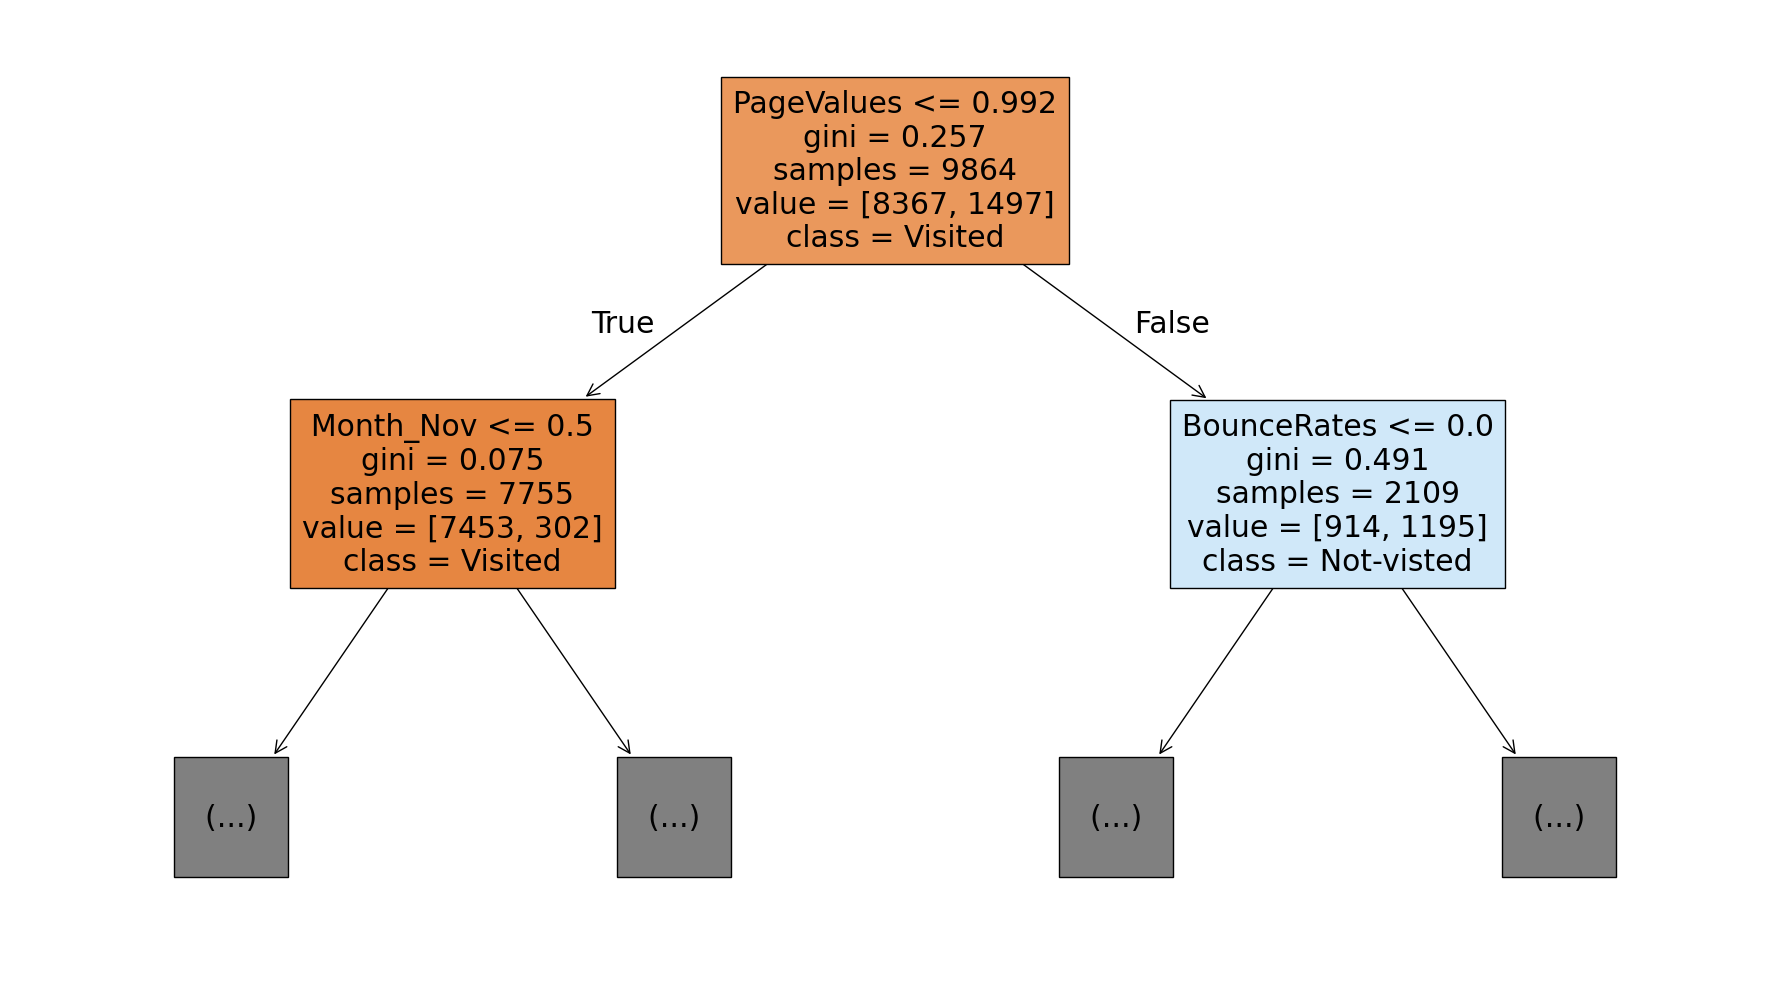

In [56]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Visited","Not-visted"],
    filled=True,
    max_depth=1
)
plt.tight_layout()
plt.show()

# Pre-purning Decsion trees

In [57]:
max_depth=[1,2,3,4,5,6,7,8]
for depth in max_depth:
   model=DecisionTreeClassifier(max_depth=depth)
   model.fit(X_train,y_train)
   acc=model.score(X_test,y_test)
   print(f"for accuracy{depth} is {acc}")

#from the is is can conclude that at the depth 6 the accuracy of the model is maximaxium among all so we can conclude that max_depth will be 6 

#now we are checkecting simlar for  min_samples_split

min_samples_split=[2,10,15,20,25,30]
for  split in min_samples_split:
   model=DecisionTreeClassifier(min_samples_split= split )
   model.fit(X_train,y_train)
   acc=model.score(X_test,y_test)
   print(f"for accuracy{ split } is {acc}")

#so from this ar split 25 we get maximum accuray so we can use 25 min_sample split at end we can combined it as

for accuracy1 is 0.8722627737226277
for accuracy2 is 0.8763179237631792
for accuracy3 is 0.8884833738848338
for accuracy4 is 0.8929440389294404
for accuracy5 is 0.8884833738848338
for accuracy6 is 0.8929440389294404
for accuracy7 is 0.8901054339010543
for accuracy8 is 0.8884833738848338
for accuracy2 is 0.8560421735604218
for accuracy10 is 0.8665855636658556
for accuracy15 is 0.878345498783455
for accuracy20 is 0.8819951338199513
for accuracy25 is 0.8856447688564477
for accuracy30 is 0.884022708840227


In [62]:
#combining the value to get maxium accuary as
model=DecisionTreeClassifier(max_depth=None,min_samples_split=25)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score
score = f1_score(y_test, y_pred)
print("f1 score is: ",score)
print("accuracy: ",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
#so after the purning process we can generally see that the f1 score an model accuary is increased

f1 score is:  0.6228646517739816
accuracy:  0.883617193836172

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      2055
           1       0.68      0.58      0.62       411

    accuracy                           0.88      2466
   macro avg       0.80      0.76      0.78      2466
weighted avg       0.88      0.88      0.88      2466


Confusion Matrix:
 [[1942  113]
 [ 174  237]]


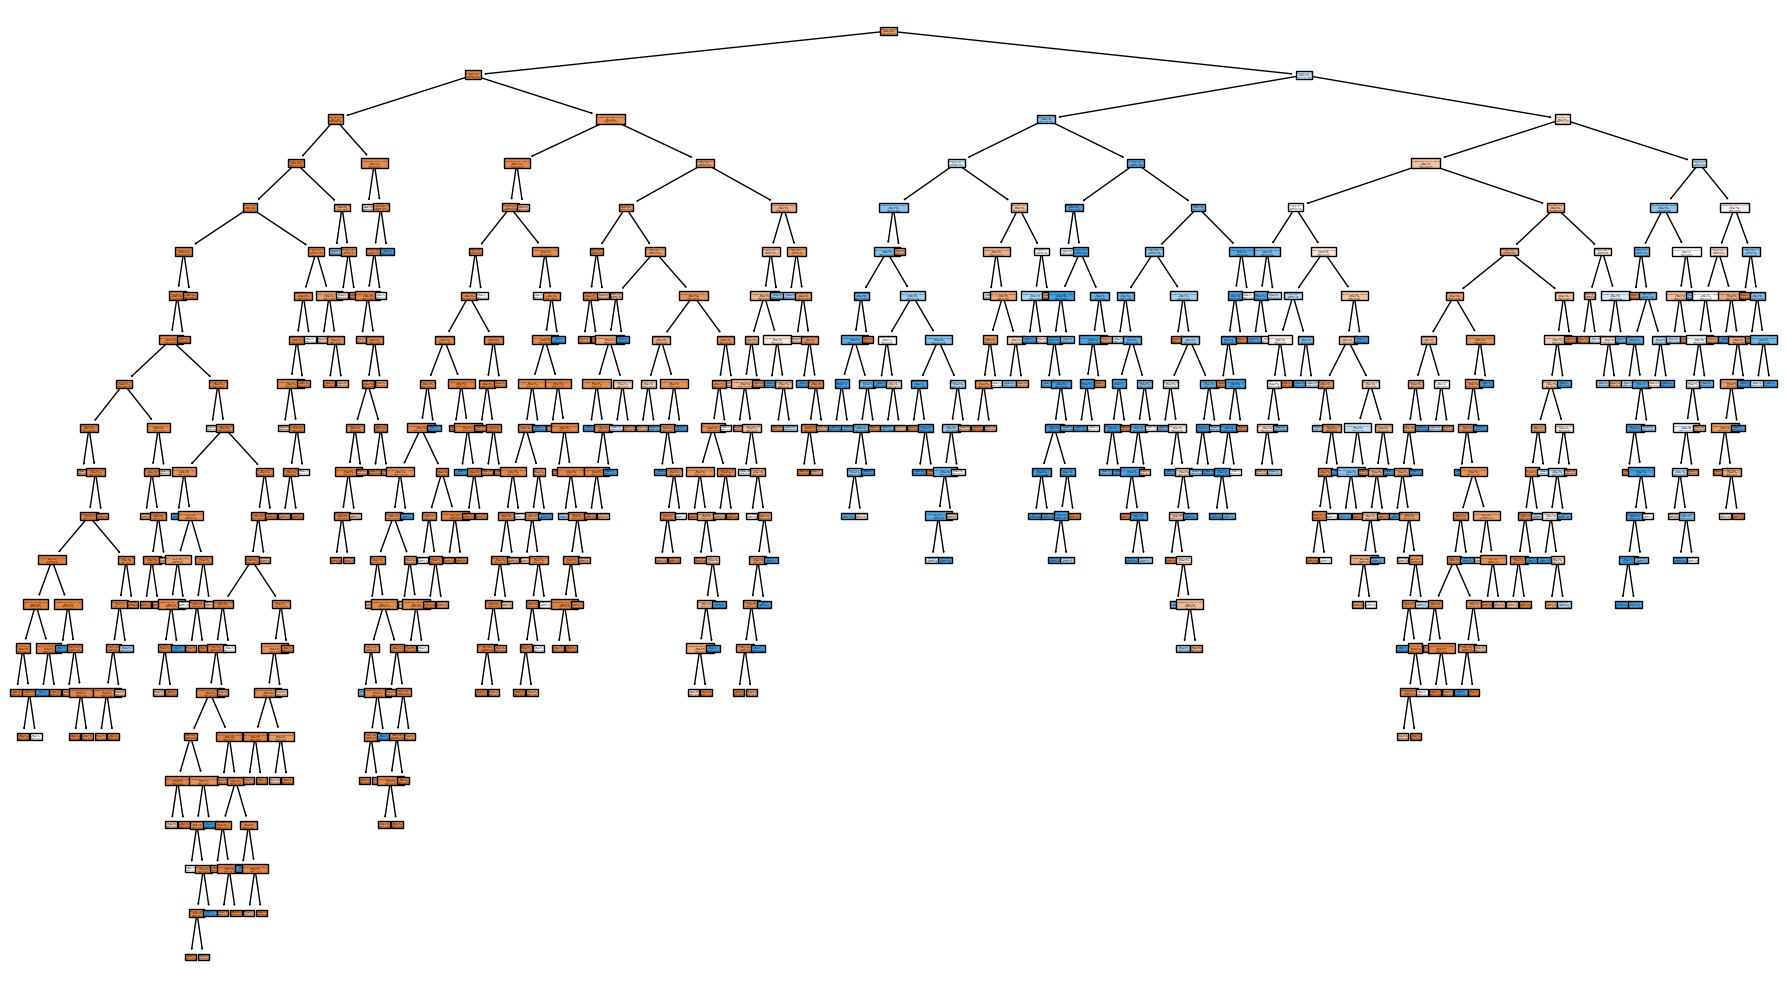

In [59]:
plt.figure(figsize=(18,10))
plot_tree(
  model,
  feature_names=X.columns,
  class_names=["Visited","Not-visted"],
  filled=True,
  
         )
plt.tight_layout()
plt.show()

# HyperParameter Tuning

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
# Preprocessng Pipeline

X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

dt = DecisionTreeClassifier(
    max_depth=6,              # prevents deep overfitting
    min_samples_leaf=30,      # smooths decision boundaries
    class_weight="balanced",  # handles imbalance
    random_state=42
)
pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", dt)
    ]
)
param_grid = {
    "model__max_depth": [4, 6, 8],
    "model__min_samples_leaf": [20, 30, 50]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best F1:", grid.best_score_)
print("Best params:", grid.best_params_)

Best F1: 0.6295841821702071
Best params: {'model__max_depth': 4, 'model__min_samples_leaf': 50}
